In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

result_folder = "../data/result"
path = final_csv = f"{result_folder}/df_final.csv"
df = pd.read_csv(path, delimiter=',')
print(df.info())


# --- 1. Separar variables ---
# Quitamos columnas que no usaremos como features directos
X = df.drop(["HC50", "label"], axis=1)

# Variable objetivo
y = df["label"]

# --- 2. Partir en entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Entrenar modelo RF ---
rf = RandomForestClassifier(
    n_estimators=300,   # más árboles = más robusto
    max_depth=None,
    random_state=42,
    class_weight="balanced"  # útil si tus clases están desbalanceadas
)
rf.fit(X_train, y_train)

# --- 4. Evaluar ---
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# --- 5. Importancia de variables ---
importances = pd.Series(rf.feature_importances_, index=X.columns)
print("\nTop 10 descriptores más importantes:")
print(importances.sort_values(ascending=False).head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HC50           1599 non-null   float64
 1   A              1599 non-null   float64
 2   AATS0Z         1599 non-null   float64
 3   AATS0d         1599 non-null   float64
 4   AATS0i         1599 non-null   float64
 5   AATS5i         1599 non-null   float64
 6   AATS6i         1599 non-null   float64
 7   AATSC1Z        1599 non-null   float64
 8   AATSC1dv       1599 non-null   float64
 9   AATSC1i        1599 non-null   float64
 10  AATSC2Z        1599 non-null   float64
 11  AATSC2i        1599 non-null   float64
 12  AATSC2s        1599 non-null   float64
 13  AATSC3Z        1599 non-null   float64
 14  AATSC3v        1599 non-null   float64
 15  AATSC5Z        1599 non-null   float64
 16  AATSC5dv       1599 non-null   float64
 17  AATSC5v        1599 non-null   float64
 18  AATSC8Z 

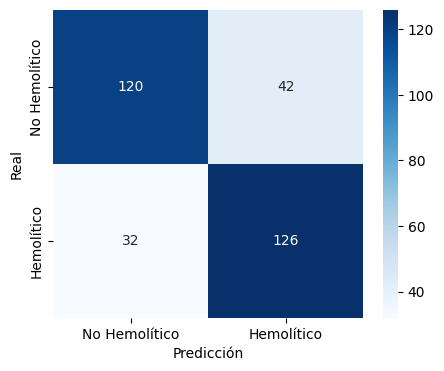

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Hemolítico", "Hemolítico"], yticklabels=["No Hemolítico", "Hemolítico"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


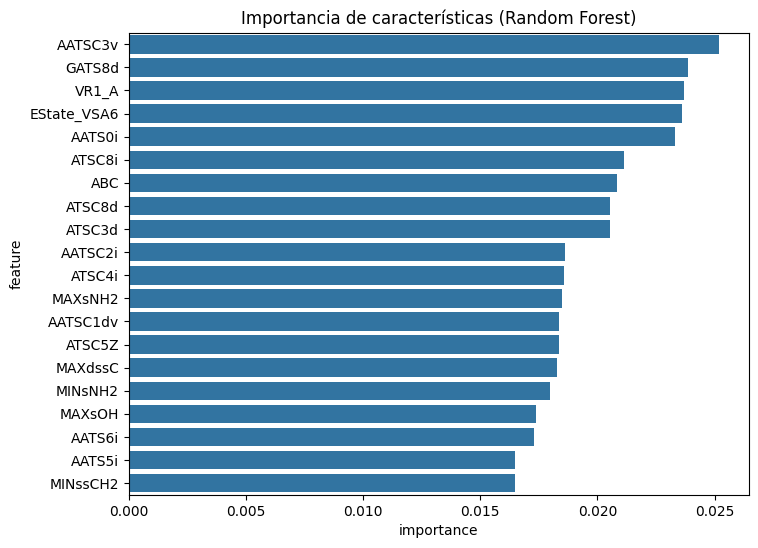

In [10]:
import pandas as pd

importances = rf.feature_importances_
feat_names = X.columns  

fi_df = pd.DataFrame({"feature": feat_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(20)  # top 20

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=fi_df)
plt.title("Importancia de características (Random Forest)")
plt.show()


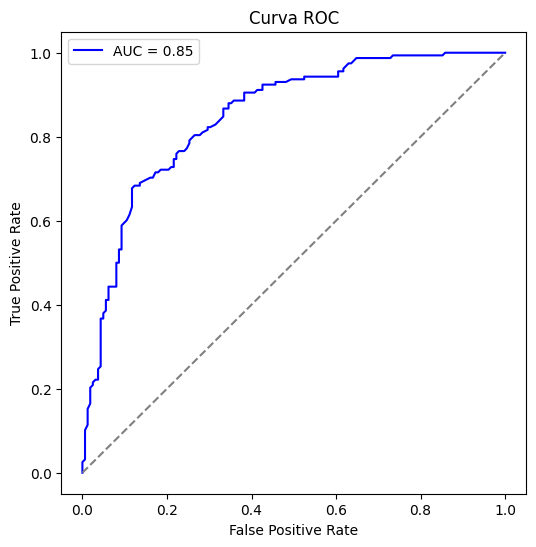

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score, classification_report
)

In [15]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score, classification_report
)
# --- 4. Evaluar ---
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # Probabilidades clase positiva (para AUC)

# --- 5. Métricas ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)


print("\n===== MÉTRICAS DEL MODELO =====")
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Cohen's Kappa: {kappa:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"AUC-ROC: {auc:.3f}")

print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


===== MÉTRICAS DEL MODELO =====
Accuracy: 0.769
Precision: 0.750
Recall: 0.797
F1-score: 0.773
Cohen's Kappa: 0.538
MCC: 0.539
AUC-ROC: 0.850

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76       162
           1       0.75      0.80      0.77       158

    accuracy                           0.77       320
   macro avg       0.77      0.77      0.77       320
weighted avg       0.77      0.77      0.77       320

